In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from termcolor import cprint
from pathlib import Path
import pandas as pd
import os
import results_analysis_utils as rutils
import matplotlib.pyplot as plt
import seaborn as sn

%load_ext autoreload
%autoreload 2


# Configuración estética para artículos científicos (Paper-ready)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.dpi'] = 200 # Alta resolución
plt.rcParams['savefig.dpi'] = 200

one_fish_gt = {"2024_11_12":31.5, "2024_11_28":28.9,"2025_05_08":33.5,"2025_08_21":29.1}

# Choose video day
folder_code ="2024_11_12"

# Parámetros Globales
ROOT_DIR = "/home/slimbook/fish_sizing/ARTICLE/1_peix/"+folder_code
ASPECT_RATIO_THR = 3.0
ANGLE_THR = 20.0

df=[]

cprint(f"Processing fish videos recorded on the date {folder_code} ","blue")
cprint(f"ROOT DIR IS {ROOT_DIR} ","blue")

gt = one_fish_gt[folder_code]
cprint(f"✅ Ground Truth is the same for all videos with a single fish: {gt}","magenta")



Processing fish videos recorded on the date 2024_11_12 
ROOT DIR IS /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_11_12 
✅ Ground Truth is the same for all videos with a single fish: 31.5


In [2]:

folder_code ="2024_11_12"
ROOT_DIR = "/home/slimbook/fish_sizing/ARTICLE/1_peix/"+folder_code

df_raw_agg_2024_11_12 = rutils.create_df_from_root_folders(root_dir= ROOT_DIR, output_csv_path=ROOT_DIR ,results_dir="corrected_results", gt=one_fish_gt[folder_code])


folder_code ="2024_11_28"
ROOT_DIR = "/home/slimbook/fish_sizing/ARTICLE/1_peix/"+folder_code
df_raw_agg_2024_11_28 = rutils.create_df_from_root_folders(root_dir= ROOT_DIR, output_csv_path=ROOT_DIR ,results_dir="corrected_results", gt=one_fish_gt[folder_code])


folder_code ="2025_05_08"
ROOT_DIR = "/home/slimbook/fish_sizing/ARTICLE/1_peix/"+folder_code
df_raw_agg_2025_05_08 = rutils.create_df_from_root_folders(root_dir= ROOT_DIR, output_csv_path=ROOT_DIR ,results_dir="corrected_results", gt=one_fish_gt[folder_code])

# Lista de DataFrames
dfs = [
    df_raw_agg_2024_11_12,
    df_raw_agg_2024_11_28,
    df_raw_agg_2025_05_08
]

# Concatenar verticalmente (apilarlos)
df_raw_agg_pool = pd.concat(dfs, axis=0, ignore_index=True)

# Revisar
print(df_raw_agg_pool.shape)
print(df_raw_agg_pool.head())

folder_code ="2025_08_21"
ROOT_DIR = "/home/slimbook/fish_sizing/ARTICLE/1_peix/"+folder_code
df_raw_agg_2025_08_21 = rutils.create_df_from_root_folders(root_dir= ROOT_DIR, output_csv_path=ROOT_DIR ,results_dir="corrected_results", gt=one_fish_gt[folder_code])


df_raw_agg_2025_08_21.head()



Buscando datos RAW en: /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_11_12
Procesando csv:  /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_11_12/10_44_11/0/results_article_basic_nou/corrected_results/10_44_11_0_raw.csv
FOLDER CODE IS:  10_44_11-0
Procesando csv:  /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_11_12/10_54_07/0/results_article_basic_nou/corrected_results/10_54_07_0_raw.csv
FOLDER CODE IS:  10_54_07-0
Procesando csv:  /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_11_12/11_10_50/0/results_article_basic_nou/corrected_results/11_10_50_0_raw.csv
FOLDER CODE IS:  11_10_50-0
Procesando csv:  /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_11_12/11_00_27/0/results_article_basic_nou/corrected_results/11_00_27_0_raw.csv
FOLDER CODE IS:  11_00_27-0
Procesando csv:  /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_11_12/10_58_20/0/results_article_basic_nou/corrected_results/10_58_20_0_raw.csv
FOLDER CODE IS:  10_58_20-0
Procesando csv:  /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_

,video_day,source_folder,frame_id,class_name,object_id,track_id,is_3D_complete,in_image_borders,does_overlap,is_front_fish,...,fish_direction,elevation_deg,azimuth_deg,raw_length,filtered_length,spine_length,gt,abs_error_cm,rel_error_%,fish_dist_from_camera
0,1_peix,2025_08_21-12_09_03,frame_0,0,255,1,-1,False,False,True,...,NaN,67.619721,37.106544,-1.0,0.322840,0.316668,29.1,3.184030,11.709446,1.663082
1,1_peix,2025_08_21-12_09_03,frame_1,0,255,1,-1,False,False,True,...,NaN,66.080659,37.133779,-1.0,0.308119,0.328139,29.1,1.711855,6.615414,1.659265
2,1_peix,2025_08_21-12_09_03,frame_2,0,255,1,-1,False,False,True,...,NaN,50.109826,25.106295,-1.0,0.249701,0.228324,29.1,4.129863,13.598142,1.693085
3,1_peix,2025_08_21-12_09_03,frame_3,0,255,1,-1,False,False,True,...,NaN,58.247246,14.057908,-1.0,0.300613,0.282332,29.1,0.961328,4.018435,1.678158
4,1_peix,2025_08_21-12_09_03,frame_4,0,255,1,-1,False,False,True,...,NaN,44.696387,13.541004,-1.0,0.257552,0.244369,29.1,3.344761,10.881526,1.710066


In [3]:

df_3d_measures=df_raw_agg[df_raw_agg["filtered_length"] > 0]


cprint(df_raw_agg.describe(),"red")
cprint(df_3d_measures.describe(),"green")
output_path = Path(ROOT_DIR) / f"{folder_code}_raw_3d_aggregated.csv"

df_3d_measures.to_csv(output_path, index=False)
 
df_3d_measures.head()



       class_name    object_id     track_id  is_3D_complete  aspect_ratio  \
count      2170.0  2170.000000  2170.000000     2170.000000   2170.000000   
mean          0.0   251.463594    20.639631        0.891705      3.518527   
std           0.0    21.213134    16.364427        0.310824      1.128983   
min           0.0    85.000000    -1.000000        0.000000      1.017788   
25%           0.0   255.000000     6.000000        1.000000      2.873239   
50%           0.0   255.000000    16.000000        1.000000      3.537750   
75%           0.0   255.000000    38.000000        1.000000      4.120878   
max           0.0   255.000000    72.000000        1.000000     12.449745   

       elevation_deg  azimuth_deg  raw_length  filtered_length  spine_length  \
count     908.000000   908.000000  908.000000       908.000000    908.000000   
mean        5.929135    20.457837    0.359882         0.292666      0.300785   
std        30.683125    67.272349    0.861701         0.114226    

,video_day,source_folder,frame_id,class_name,object_id,track_id,is_3D_complete,in_image_borders,does_overlap,is_front_fish,...,fish_direction,elevation_deg,azimuth_deg,raw_length,filtered_length,spine_length,gt,abs_error_cm,rel_error_%,fish_dist_from_camera
66,2024_11_12,10_44_11-0,frame_108,0,255,3,1,False,False,True,...,[ -0.047796 -0.32801 0.94346],3.714765,9.934494,2.376050,0.428248,0.424896,31.5,11.324795,35.951729,0.699576
70,2024_11_12,10_44_11-0,frame_115,0,255,3,1,False,False,True,...,NaN,-0.037580,14.808503,-1.000000,0.435934,0.436737,31.5,12.093409,38.391774,0.692552
72,2024_11_12,10_44_11-0,frame_118,0,255,3,1,False,False,True,...,NaN,2.226477,9.253469,-1.000000,0.434911,0.434006,31.5,11.991052,38.066833,0.712949
77,2024_11_12,10_44_11-0,frame_126,0,255,3,1,False,False,True,...,[ 0.50741 -0.14805 0.84889],-0.429623,15.376115,1.665510,0.429357,0.420976,31.5,11.435654,36.303662,0.692104
120,2024_11_12,10_44_11-0,frame_285,0,255,3,1,False,False,True,...,[ 0.38489 -0.41355 0.82513],3.500313,-21.627361,1.916571,0.304956,0.279093,31.5,1.004354,3.188425,0.694922


In [4]:
# Checks!

# Number of video seqs loaded:
video_codes = df_raw_agg["source_folder"].unique()
cprint(f"Number of video seqs is: {len(video_codes)}","yellow")
 
cprint("\n Unique video codes are","cyan")
for code in video_codes:
    cprint(code+ "\n","cyan")

Number of video seqs is: 9

 Unique video codes are
10_44_11-0

10_54_07-0

11_10_50-0

11_00_27-0

10_58_20-0

11_08_39-0

11_37_10-0

10_48_44-1

10_48_44-0



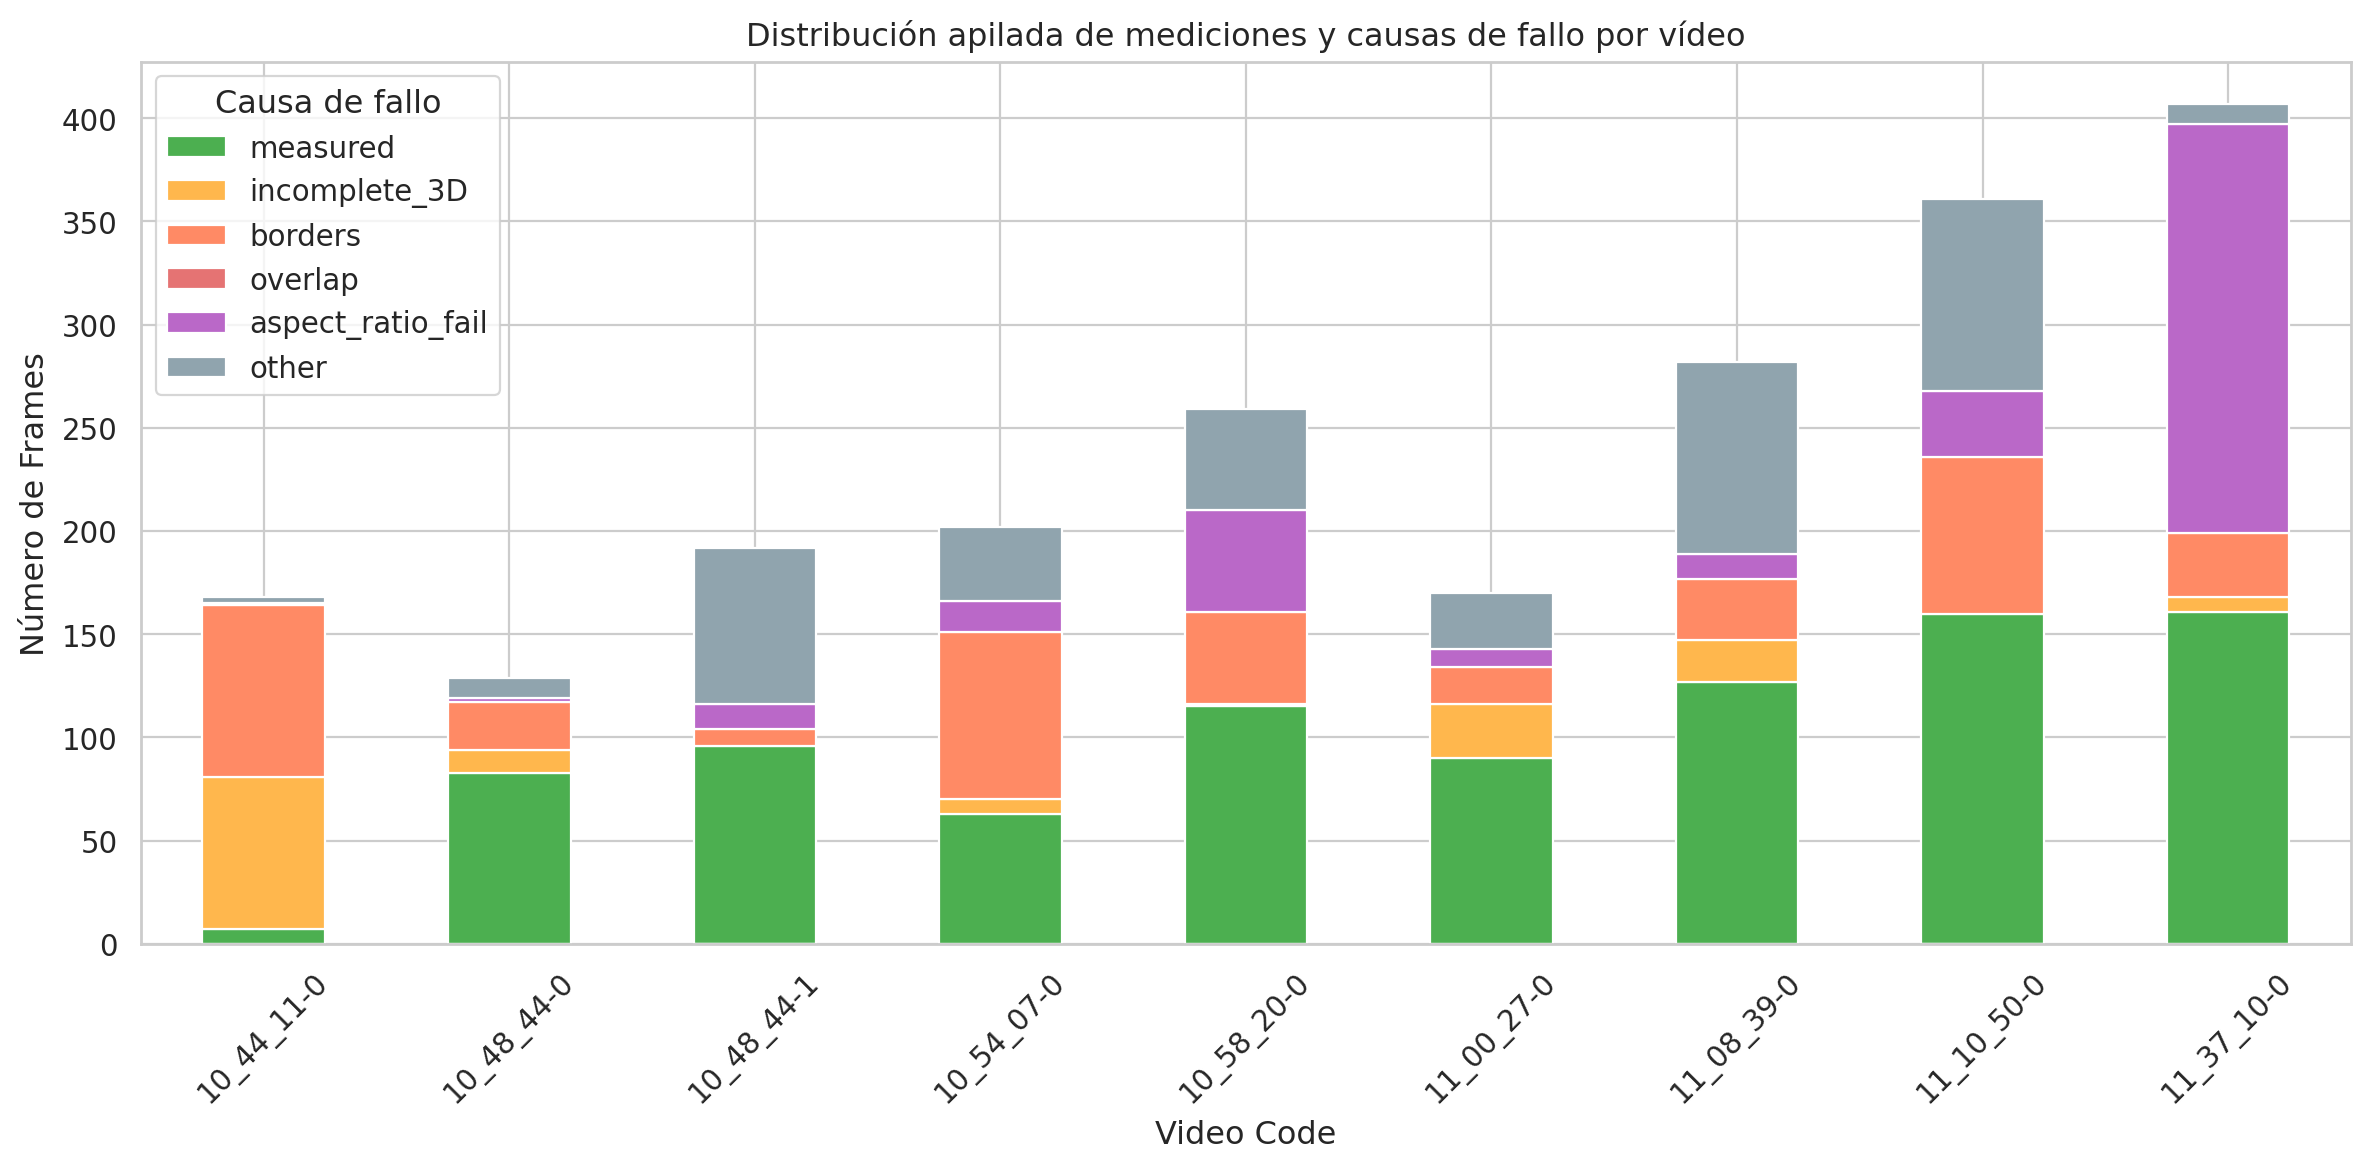

Conteo global de frames por causa:
      failure_reason  count
0           measured    902
1      incomplete_3D    146
2            borders    395
3            overlap      0
4  aspect_ratio_fail    330
5              other    397


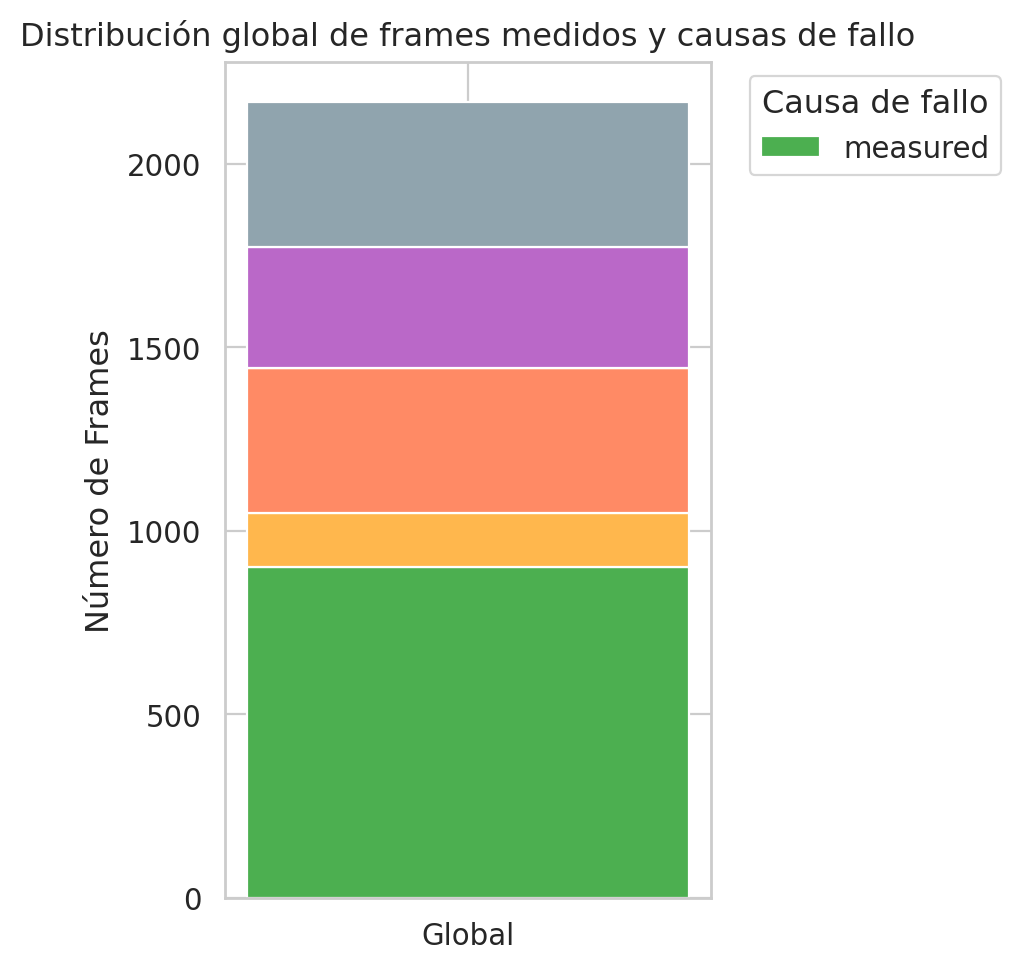

failure_reason,measured,incomplete_3D,borders,overlap,aspect_ratio_fail,other
source_folder,,,,,,
10_44_11-0,7,74,83,0,1,3
10_48_44-0,83,11,23,0,2,10
10_48_44-1,96,0,8,0,12,76
10_54_07-0,63,7,81,0,15,36
10_58_20-0,115,1,45,0,49,49
11_00_27-0,90,26,18,0,9,27
11_08_39-0,127,20,30,0,12,93
11_10_50-0,160,0,76,0,32,93
11_37_10-0,161,7,31,0,198,10


In [ ]:


df_raw_agg['unique_track'] = df_raw_agg['source_folder'].astype(str) + "_" + df_raw_agg['track_id'].astype(str)
df_raw_agg["failure_reason"] = df_raw_agg.apply(
    lambda row: rutils.classify_failure(row, ASPECT_RATIO_THR=ASPECT_RATIO_THR),
    axis=1
)


rutils.plot_frame_failures(df_raw_agg, figsize_video=(12,6), figsize_global=(5,5), show_global=True)

rutils.plot_tracks_failure_distribution(df_raw_agg, aspect_ratio_thr=3.0, show_global=True, figsize_video=(12,6), figsize_global=(5,5))
rutils.plot_aspect_ratio_vs_length(df_raw_agg, ASPECT_RATIO_THR=ASPECT_RATIO_THR, figsize=(10, 8))

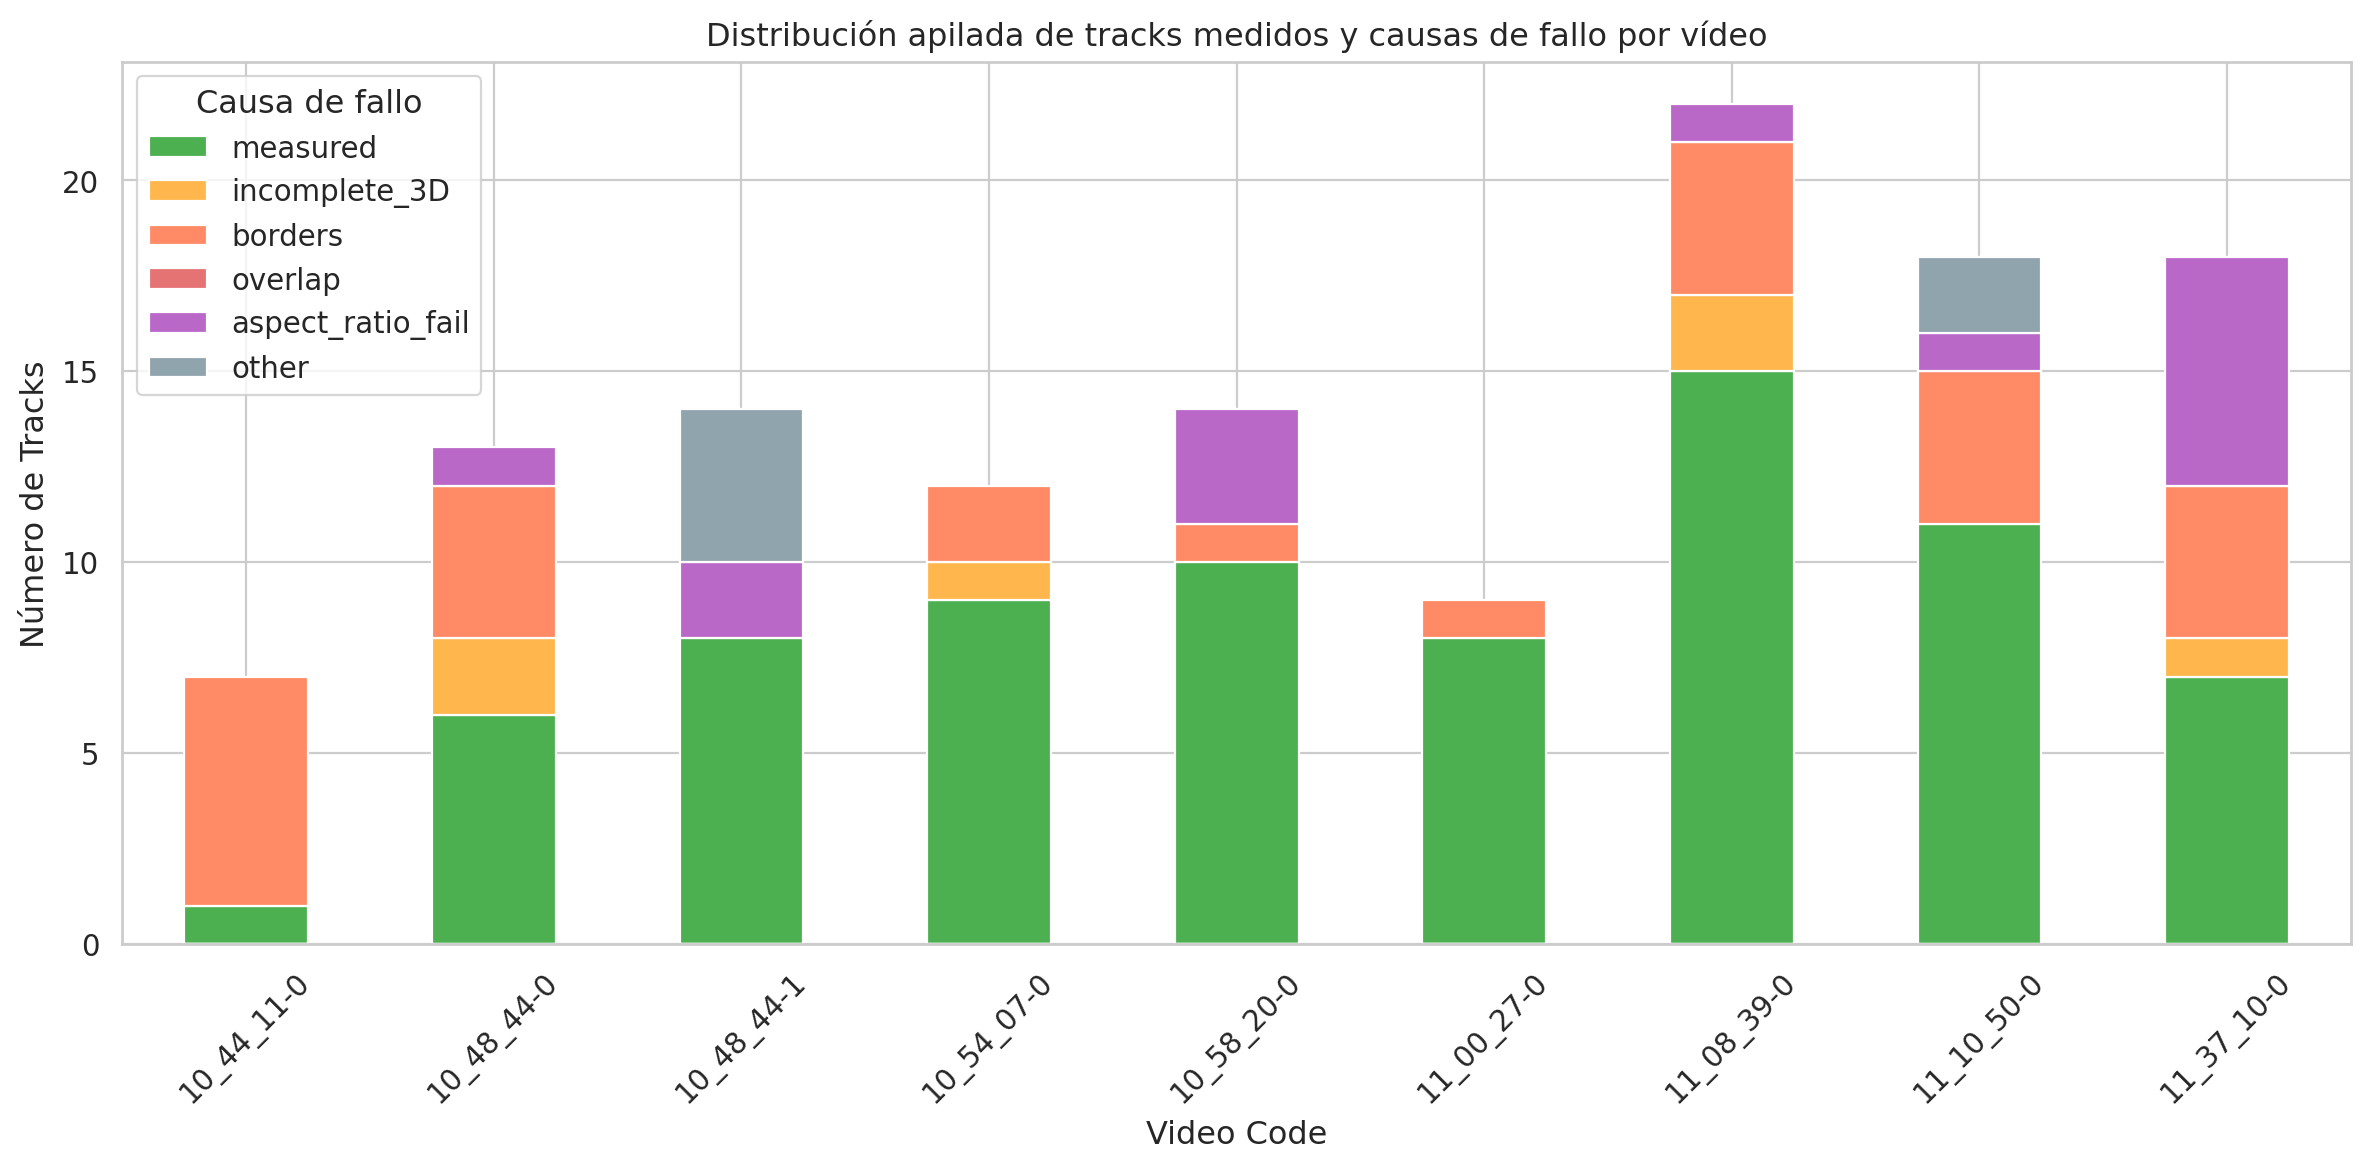

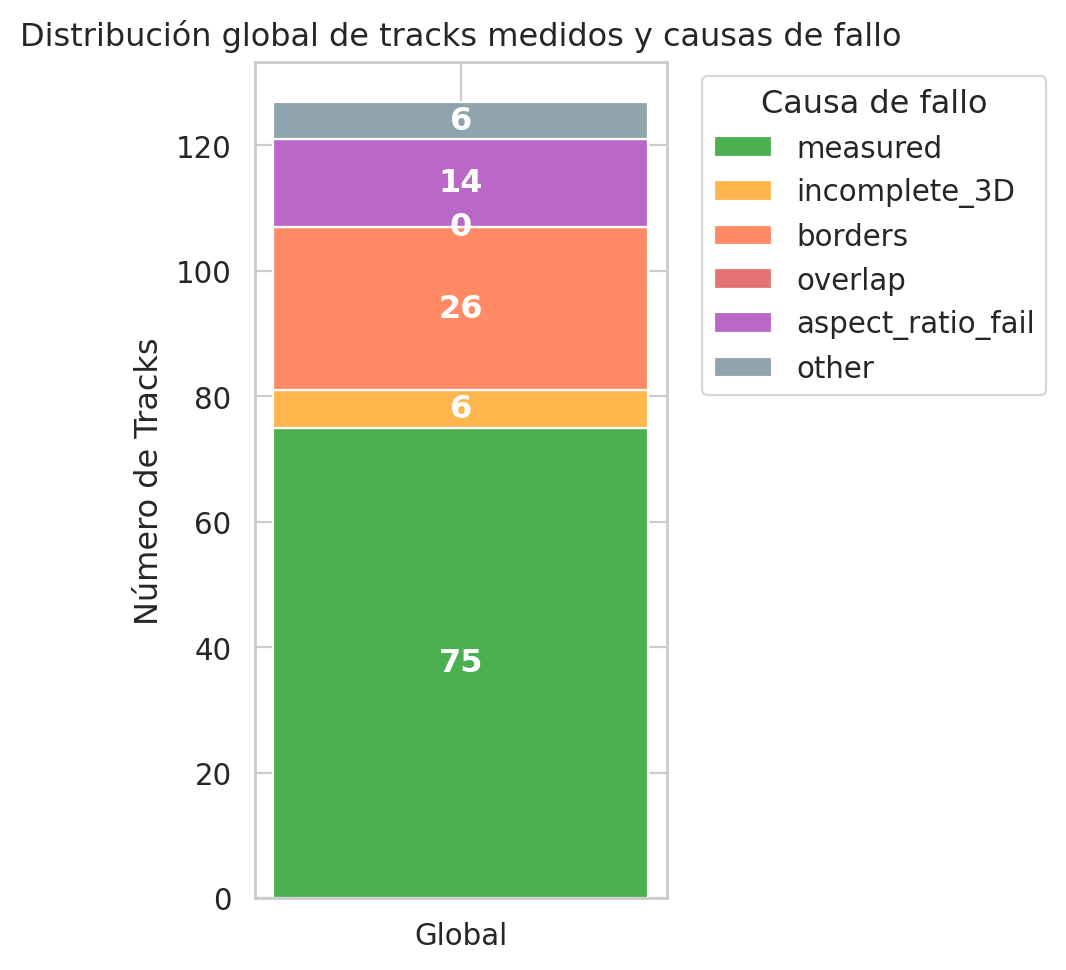

,unique_track,track_failure_reason,source_folder
0,10_44_11-0_-1,borders,10_44_11-0
1,10_44_11-0_13,borders,10_44_11-0
2,10_44_11-0_15,borders,10_44_11-0
3,10_44_11-0_3,measured,10_44_11-0
4,10_44_11-0_7,borders,10_44_11-0
...,...,...,...
122,11_37_10-0_4,aspect_ratio_fail,11_37_10-0
123,11_37_10-0_41,aspect_ratio_fail,11_37_10-0
124,11_37_10-0_44,measured,11_37_10-0
125,11_37_10-0_45,measured,11_37_10-0


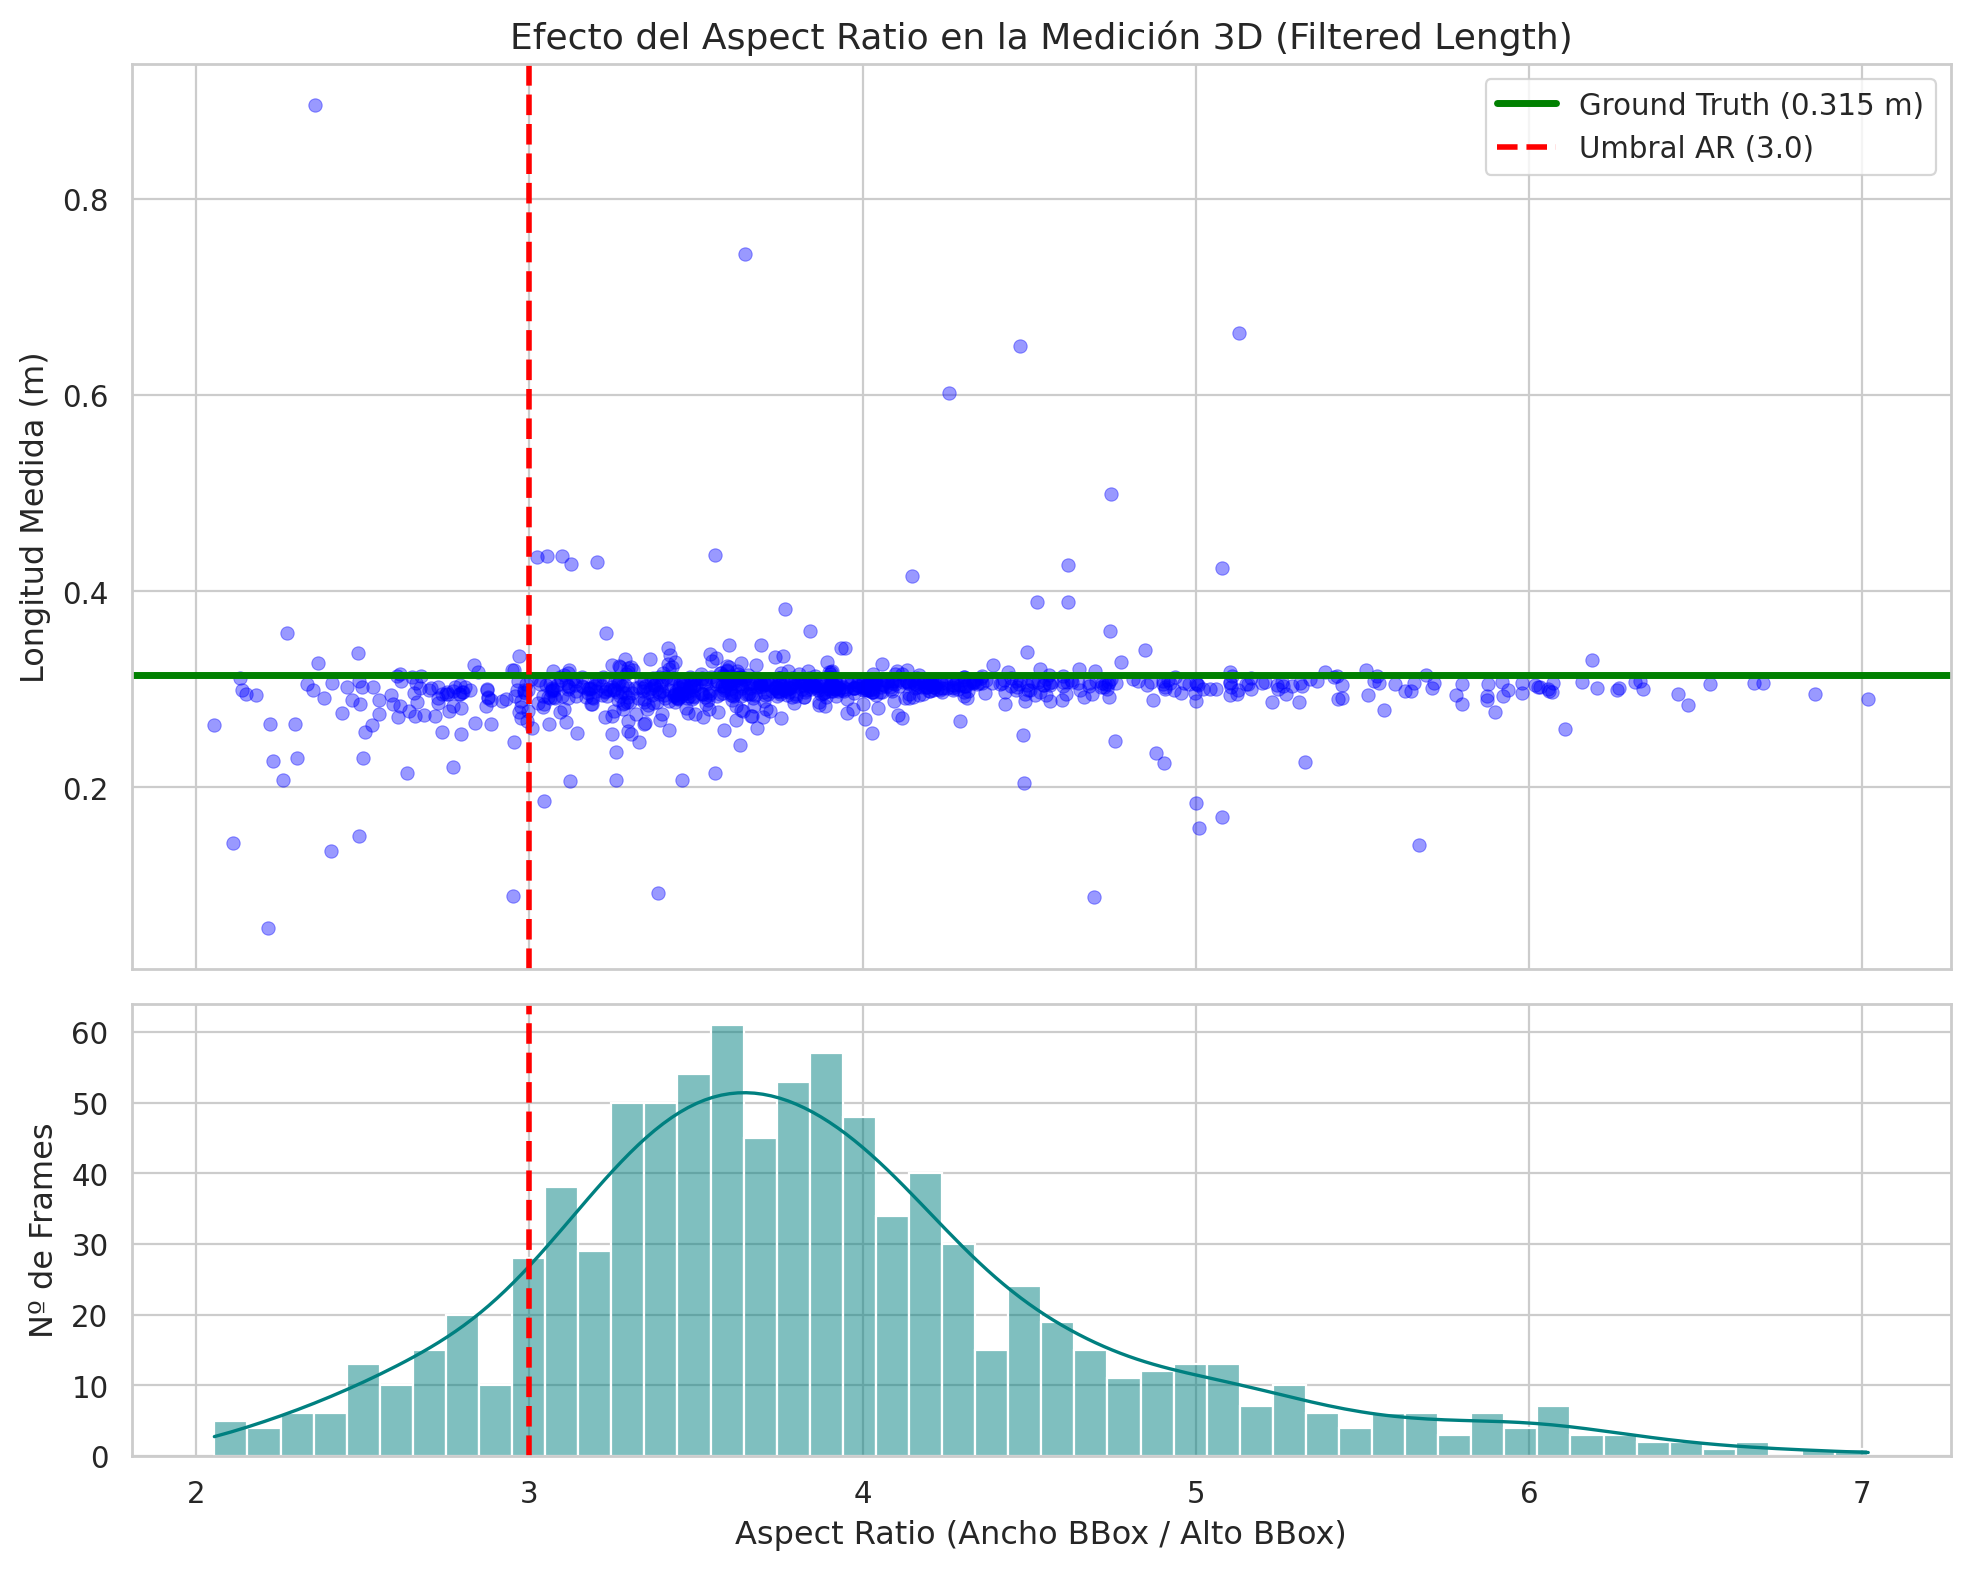

In [8]:
df_raw_agg

,video_day,source_folder,frame_id,class_name,object_id,track_id,is_3D_complete,in_image_borders,does_overlap,is_front_fish,...,azimuth_deg,raw_length,filtered_length,spine_length,gt,abs_error_cm,rel_error_%,fish_dist_from_camera,unique_track,failure_reason
0,2024_11_12,10_44_11-0,frame_1,0,255,-1,1,False,False,True,...,NaN,NaN,NaN,NaN,31.5,NaN,NaN,NaN,10_44_11-0_-1,aspect_ratio_fail
1,2024_11_12,10_44_11-0,frame_9,0,255,-1,1,False,False,True,...,NaN,NaN,NaN,NaN,31.5,NaN,NaN,NaN,10_44_11-0_-1,other
2,2024_11_12,10_44_11-0,frame_12,0,255,-1,0,True,False,True,...,NaN,NaN,NaN,NaN,31.5,NaN,NaN,NaN,10_44_11-0_-1,borders
3,2024_11_12,10_44_11-0,frame_13,0,255,3,0,True,False,True,...,NaN,NaN,NaN,NaN,31.5,NaN,NaN,NaN,10_44_11-0_3,borders
4,2024_11_12,10_44_11-0,frame_15,0,255,3,0,True,False,True,...,NaN,NaN,NaN,NaN,31.5,NaN,NaN,NaN,10_44_11-0_3,borders
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2165,2024_11_12,10_48_44-0,frame_655,0,255,43,1,False,False,True,...,-25.386546,0.774454,0.289072,0.279093,31.5,2.592832,8.231213,0.841480,10_48_44-0_43,measured
2166,2024_11_12,10_48_44-0,frame_656,0,255,43,1,False,False,True,...,-29.343617,0.744740,0.289805,0.278997,31.5,2.519492,7.998387,0.844902,10_48_44-0_43,measured
2167,2024_11_12,10_48_44-0,frame_657,0,255,43,1,False,False,True,...,NaN,NaN,NaN,NaN,31.5,NaN,NaN,NaN,10_48_44-0_43,other
2168,2024_11_12,10_48_44-0,frame_658,0,255,43,1,True,False,True,...,NaN,NaN,NaN,NaN,31.5,NaN,NaN,NaN,10_48_44-0_43,borders


ETAPA DEL PIPELINE (CASCADA)                  | ERROR MEDIO     | FRAMES VIVOS    | PECES (TRACKS)
----------------------------------------------------------------------------------------------------
0. Base (HDBSCAN sin filtros)                 |  1.62 ± 2.78 cm |     902 frames |    45 tracks
1. + Filtro: is_3D_complete                   |  1.62 ± 2.78 cm |     902 frames |    45 tracks
2. + Filtro: Sin Bordes                       |  1.62 ± 2.78 cm |     902 frames |    45 tracks
3. + Filtro: Sin Solapamiento                 |  1.62 ± 2.78 cm |     902 frames |    45 tracks
4. + Filtro: Aspect Ratio >= 1.8              |  1.62 ± 2.78 cm |     902 frames |    45 tracks
5. + Filtro: Ángulo Z <= 20º                  |  1.69 ± 3.50 cm |     434 frames |    28 tracks


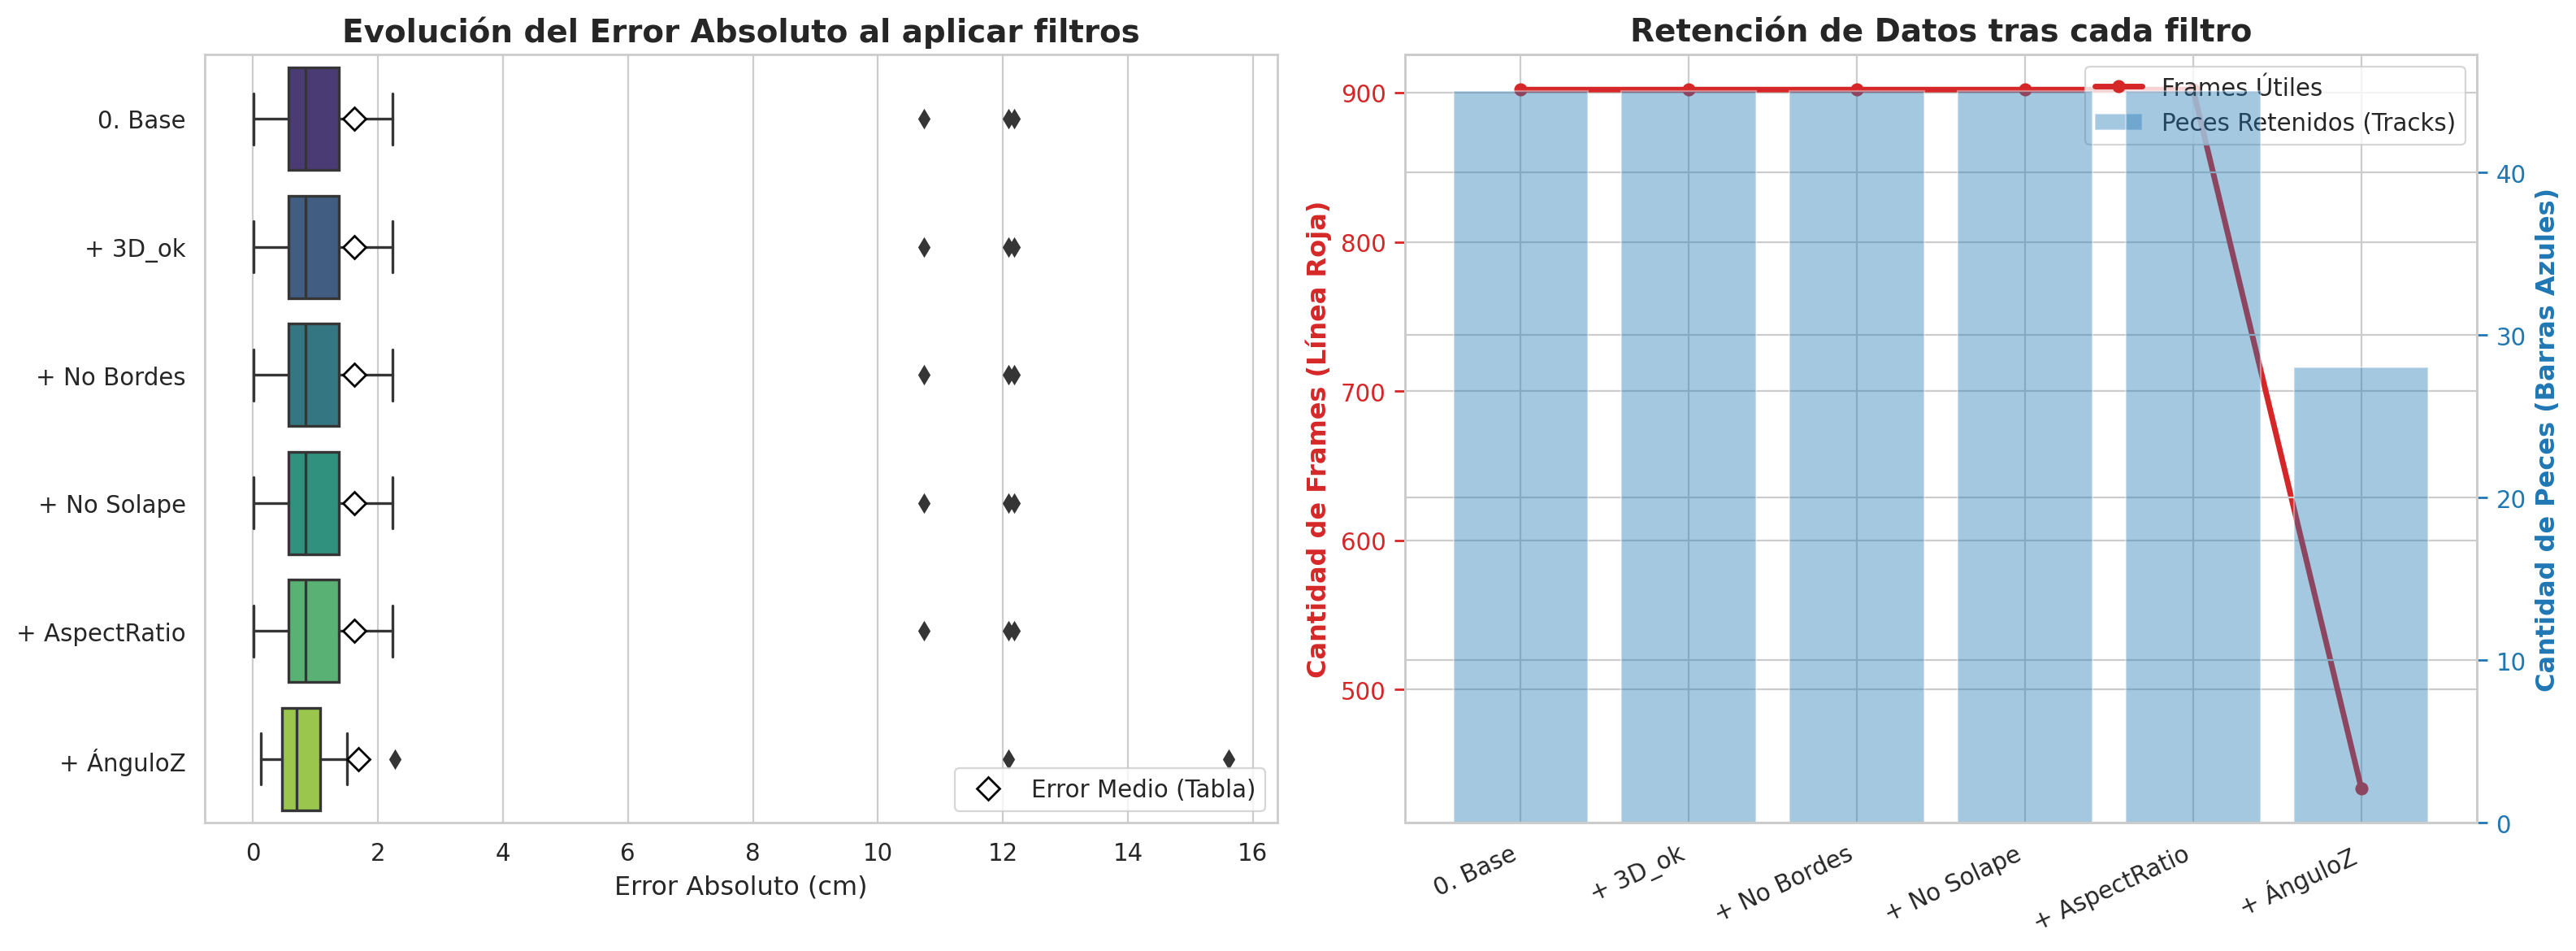

ETAPA DEL PIPELINE (CASCADA)                  | ERROR MEDIO     | FRAMES VIVOS    | PECES (TRACKS)
----------------------------------------------------------------------------------------------------
0. Base (HDBSCAN sin filtros)                 |  3.70 ± 7.49 cm |    3216 frames |    62 tracks
1. + Filtro: is_3D_complete                   |  3.17 ± 6.81 cm |    3168 frames |    60 tracks
2. + Filtro: Sin Bordes                       |  1.91 ± 3.77 cm |    2972 frames |    54 tracks
3. + Filtro: Sin Solapamiento                 |  1.91 ± 3.77 cm |    2972 frames |    54 tracks
4. + Filtro: Aspect Ratio >= 1.8              |  1.27 ± 1.81 cm |    2933 frames |    52 tracks
5. + Filtro: Ángulo Z <= 20º                  |  0.67 ± 1.00 cm |    2102 frames |    38 tracks


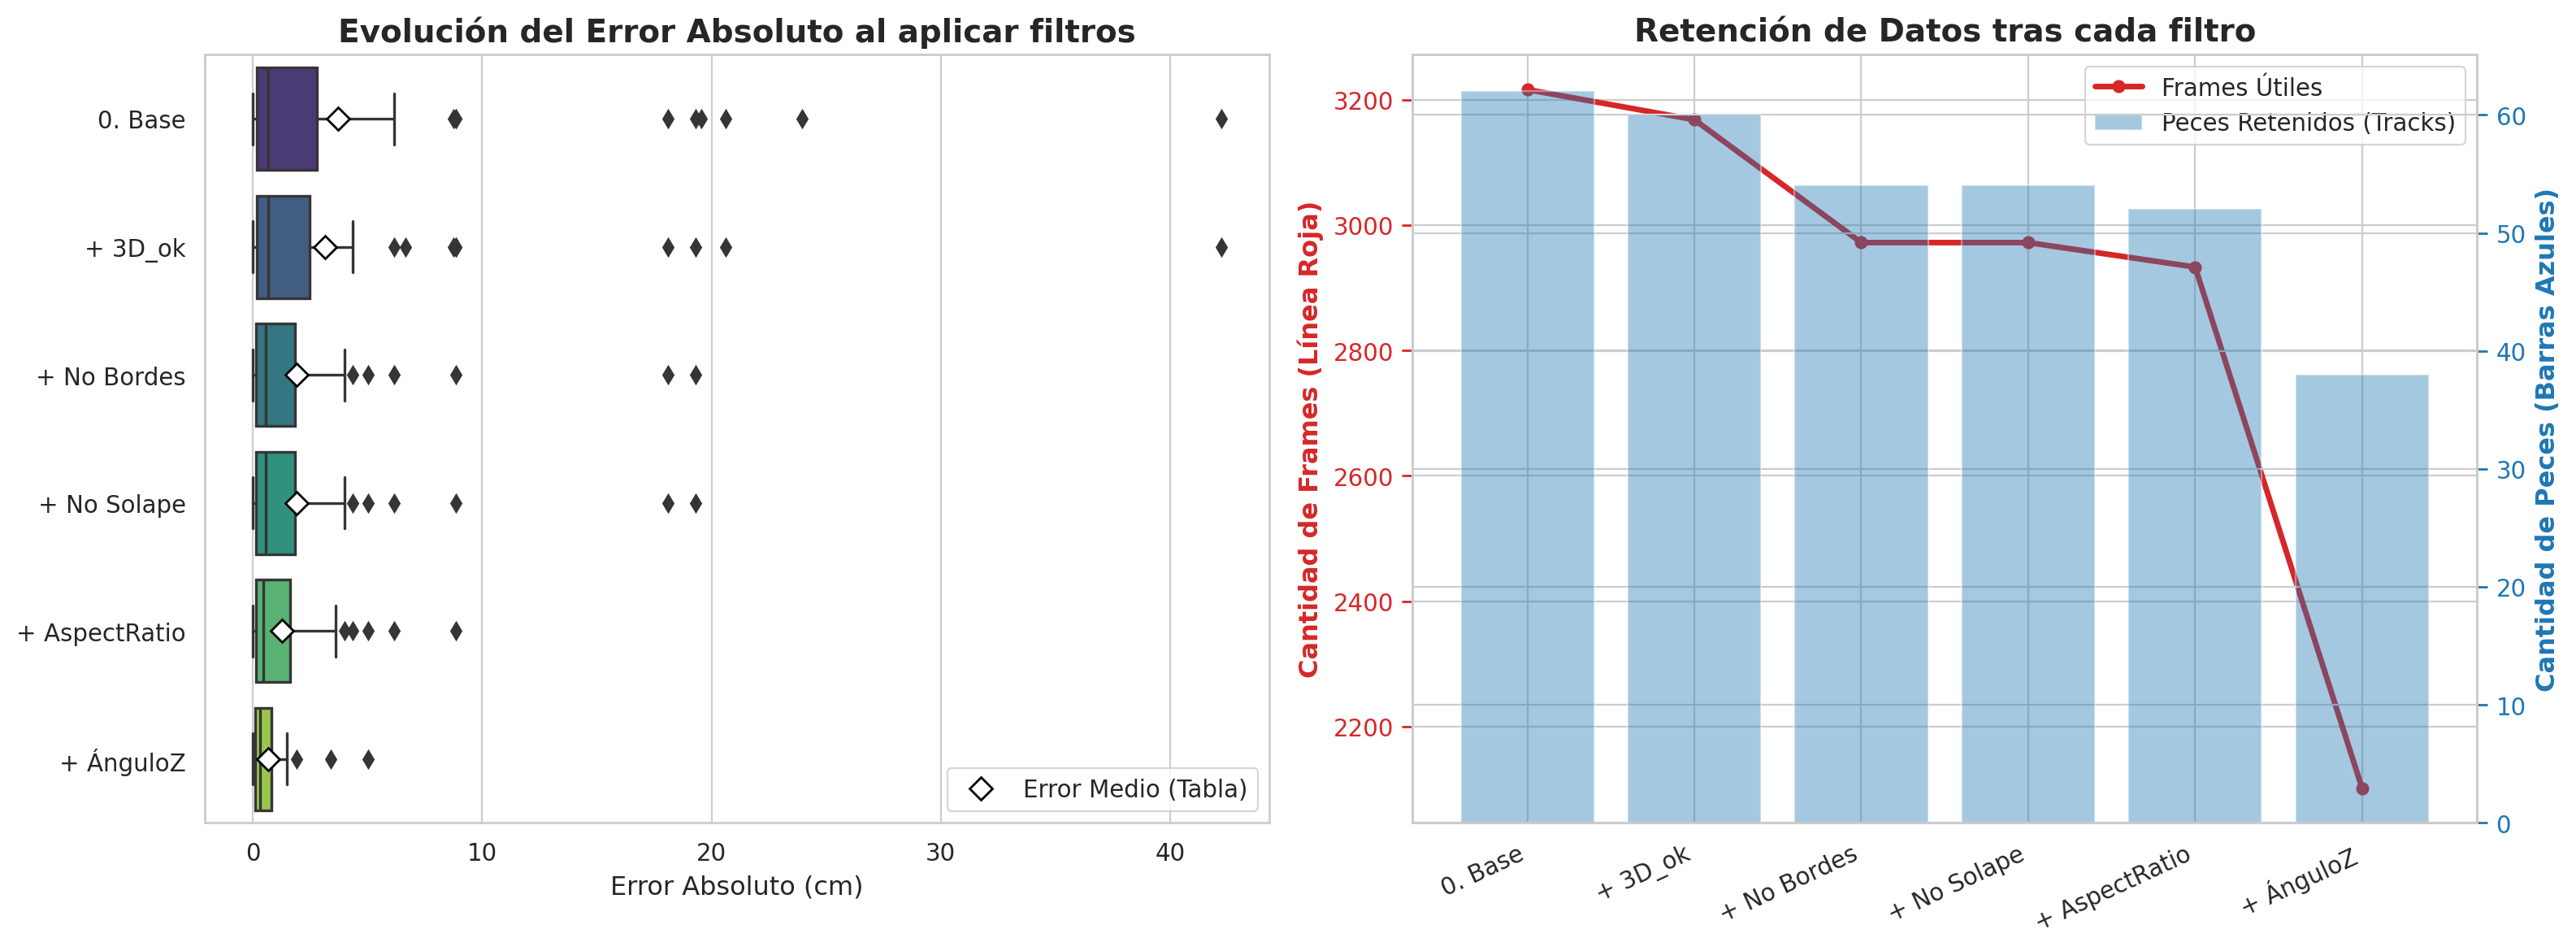

ETAPA DEL PIPELINE (CASCADA)                  | ERROR MEDIO     | FRAMES VIVOS    | PECES (TRACKS)
----------------------------------------------------------------------------------------------------
0. Base (HDBSCAN sin filtros)                 |  3.34 ± 2.06 cm |     134 frames |     5 tracks
1. + Filtro: is_3D_complete                   |  3.34 ± 2.06 cm |     134 frames |     5 tracks
2. + Filtro: Sin Bordes                       |  3.34 ± 2.06 cm |     134 frames |     5 tracks
3. + Filtro: Sin Solapamiento                 |  3.34 ± 2.06 cm |     134 frames |     5 tracks
4. + Filtro: Aspect Ratio >= 1.8              |  3.34 ± 2.06 cm |     134 frames |     5 tracks
5. + Filtro: Ángulo Z <= 20º                  |  2.07 ± 0.59 cm |      99 frames |     3 tracks


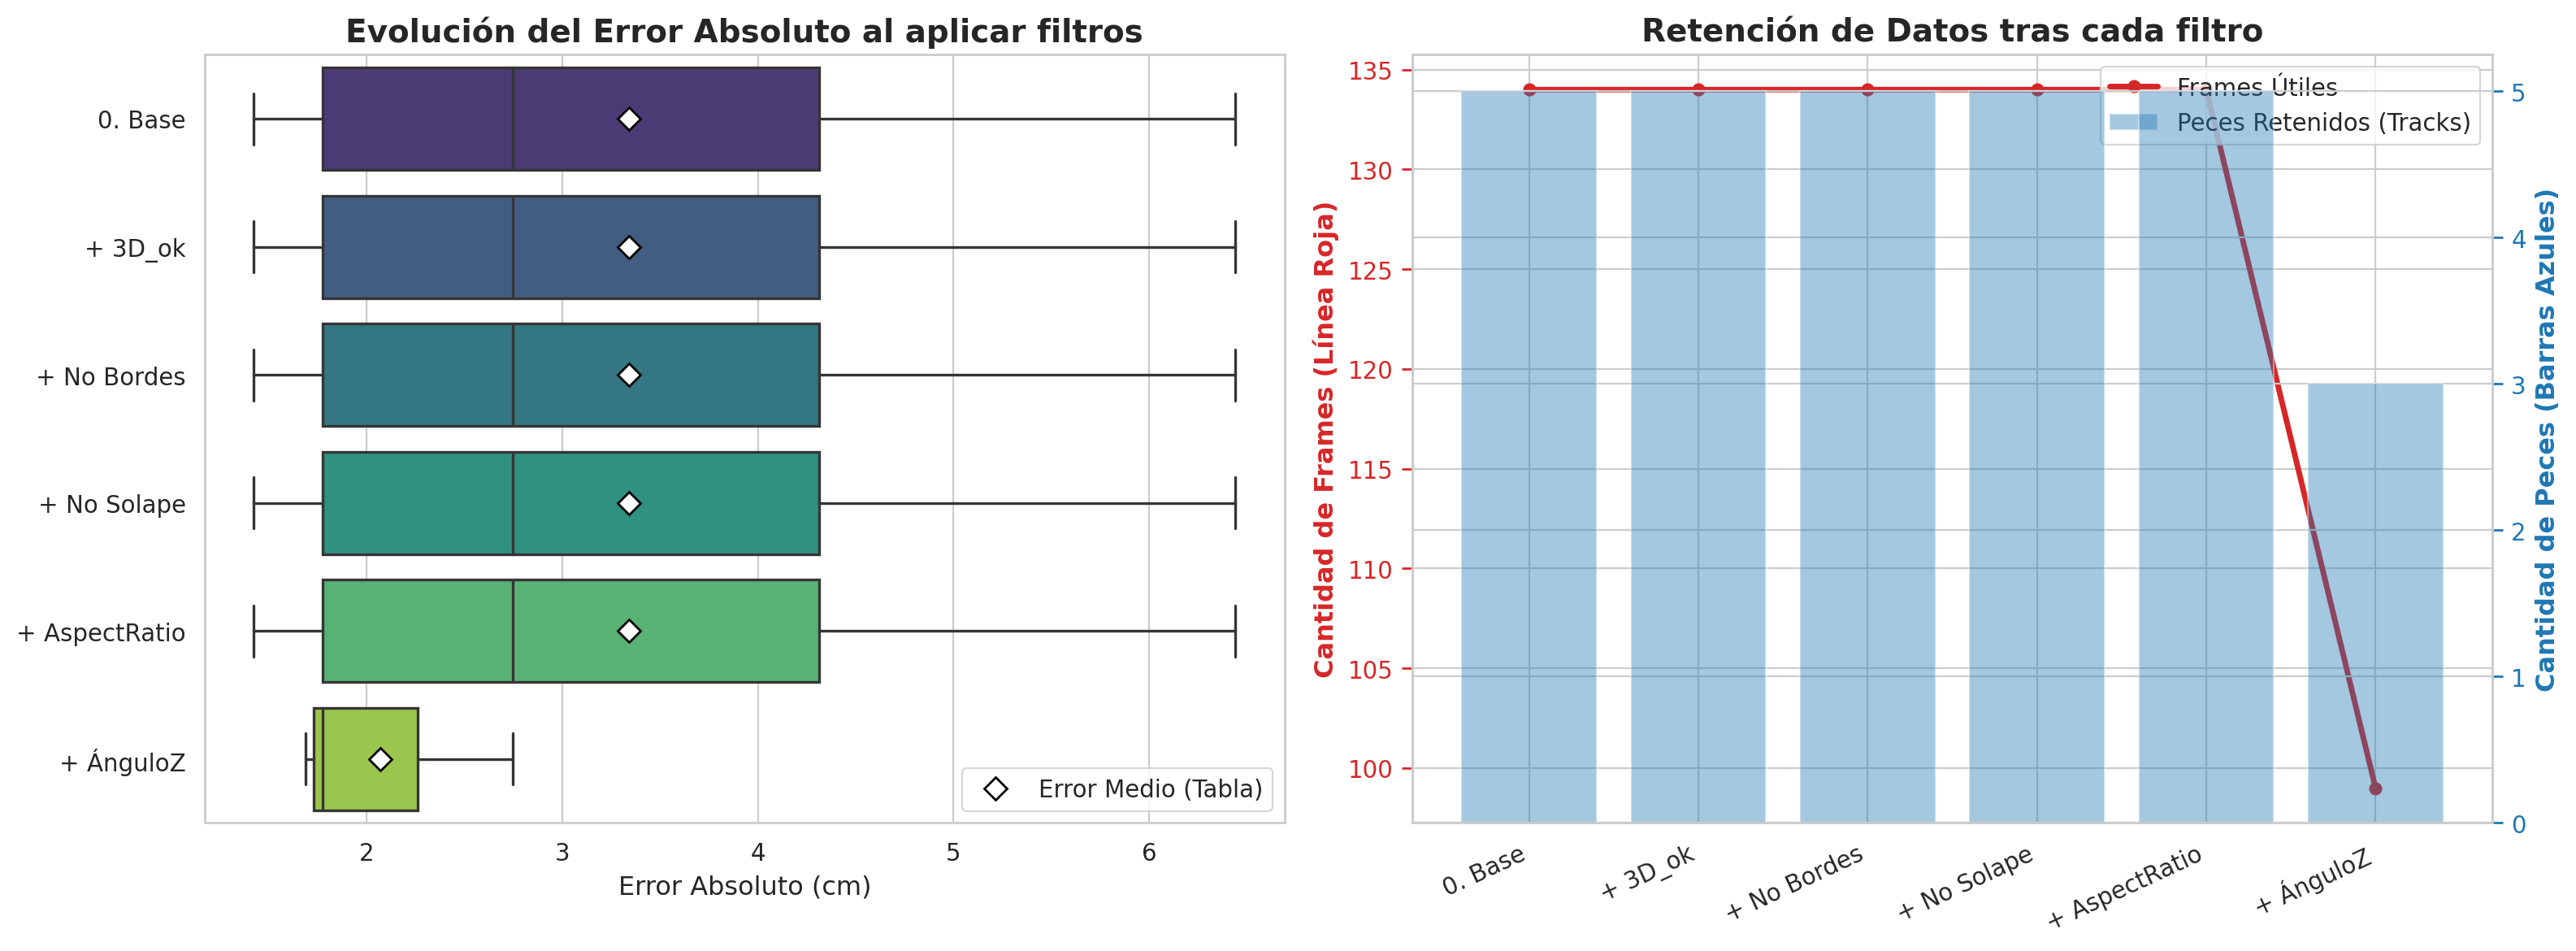

ValueError: cannot insert track_id, already exists

In [3]:
df_names = [
    "df_raw_agg_2024_11_12",
    "df_raw_agg_2024_11_28",
    "df_raw_agg_2025_05_08",
    "df_raw_agg_2025_08_21",
    "df_raw_agg_pool"
]

for df_name in df_names:
    df_raw = globals()[df_name]  # <-- toma el DataFrame real
    stages_dict, df_filtered_angle_ok = rutils.plot_ablation_pipeline(
        df_raw, ASPECT_RATIO_THR=1.8, ANGLE_THR=20
    )